In [ ]:
# ============================================================
# 1️⃣ Imports
# ============================================================
import sys
sys.path.append('/home/xilinx')

import numpy as np
import time
from PIL import Image
import matplotlib.pyplot as plt

from pynq import Overlay
from tcu_pynq.driver import Driver
from tcu_pynq.architecture import pynqz1

%matplotlib inline


# ============================================================
# 2️⃣ Load Bitstream
# ============================================================
overlay = Overlay("tensil_pynqz1.bit")

# Use smaller DMA buffer if memory issues occur
tcu = Driver(pynqz1, overlay.axi_dma_0)

print("✅ Bitstream + TCU initialized")
print("Array size:", tcu.arch.array_size)



✅ Bitstream + TCU initialized
Array size: 8


✅ Model loaded
Input nodes: ['keras_tensor_315']
Output nodes: ['output_0']

Image: images_mask/with_mask_3.jpg
Logit: -15.0625
Prediction: Mask
Latency: 28.25 ms
Throughput: 35.4 FPS


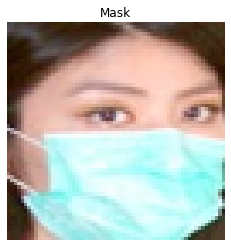


Image: images_mask/with_mask_163.jpg
Logit: -24.54296875
Prediction: Mask
Latency: 22.66 ms
Throughput: 44.13 FPS


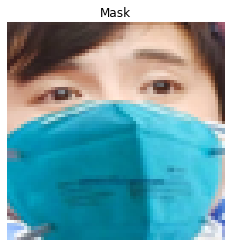


Image: images_mask/with_mask_612.jpg
Logit: -4.890625
Prediction: Mask
Latency: 26.64 ms
Throughput: 37.54 FPS


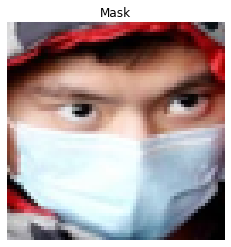


Image: images_mask/with_mask_1664.jpg
Logit: -15.078125
Prediction: Mask
Latency: 23.08 ms
Throughput: 43.32 FPS


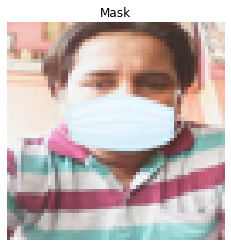


Image: images_mask/without_mask_529.jpg
Logit: 12.1015625
Prediction: No Mask
Latency: 24.18 ms
Throughput: 41.35 FPS


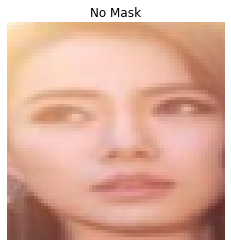


Image: images_mask/without_mask_582.jpg
Logit: 4.03125
Prediction: No Mask
Latency: 25.36 ms
Throughput: 39.44 FPS


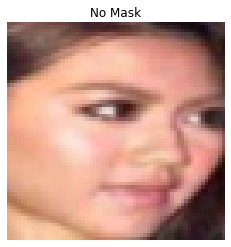


Image: images_mask/without_mask_3346.jpg
Logit: 12.01171875
Prediction: No Mask
Latency: 24.0 ms
Throughput: 41.67 FPS


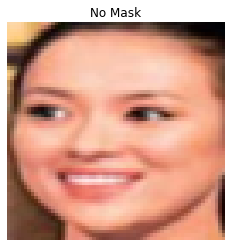


Image: images_mask/without_mask_2280.jpg
Logit: 1.93359375
Prediction: No Mask
Latency: 23.86 ms
Throughput: 41.92 FPS


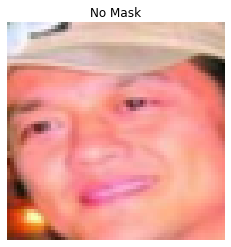

(0, 23.85544776916504, 41.919146086730564)

In [ ]:

# ============================================================
# 3️⃣ Load Compiled Model
# ============================================================
tcu.load_model("./maskmodel_with_fit_onnx_pynqz1.tmodel")

print("✅ Model loaded")

print("Input nodes:", [i.name for i in tcu.model.inputs])
print("Output nodes:", [o.name for o in tcu.model.outputs])


# ============================================================
# 4️⃣ Preprocessing (CRITICAL PART)
# ============================================================
def preprocess_image(path):
    image = Image.open(path)
    image = image.resize((64,64))
    image = image.convert("RGB")

    img = np.array(image).astype(np.float32) / 255.0

    # ---- IMPORTANT ----
    # Pad channel dimension to match vector width (array_size = 8)
    pad_channels = tcu.arch.array_size - 3
    img = np.pad(img, [(0,0), (0,0), (0,pad_channels)], mode='constant')

    # Flatten and reshape into vector-width chunks
    img = img.reshape(-1, tcu.arch.array_size)

    return image, img


# ============================================================
# 5️⃣ Inference Function
# ============================================================
# def classify(path, show_image=True):
#     original_image, img = preprocess_image(path)

#     input_name = tcu.model.inputs[0].name
#     output_name = tcu.model.outputs[0].name

#     start = time.time()
#     outputs = tcu.run({input_name: img})
#     end = time.time()

#     logit = outputs[output_name][0]

#     # Sigmoid on ARM
# #     prob = 1 / (1 + np.exp(-logit))
#     pred = 1 if logit < 0 else 0

#     label_map = {0: "No Mask", 1: "Mask"}

#     print("\nImage:", path)
#     print("Logit:", float(logit))
# #     print("Probability:", float(prob))
#     print("Prediction:", label_map[pred])
#     print("Latency:", round((end-start)*1000, 2), "ms")

#     if show_image:
#         plt.figure(figsize=(4,4))
#         plt.imshow(original_image)
#         plt.axis("off")
#         plt.title(label_map[pred])
#         plt.show()

#     return pred
def classify(path, show_image=True, runs=1):
    original_image, img = preprocess_image(path)

    input_name = tcu.model.inputs[0].name
    output_name = tcu.model.outputs[0].name

    # Run multiple times for stable measurement
    start = time.time()

    for _ in range(runs):
        outputs = tcu.run({input_name: img})

    end = time.time()

    total_time = end - start
    latency = (total_time / runs) * 1000   # ms per inference
    throughput = runs / total_time         # inferences per second (FPS)

    logit = outputs[output_name][0]

    pred = 1 if logit < 0 else 0
    label_map = {0: "No Mask", 1: "Mask"}

    print("\nImage:", path)
    print("Logit:", float(logit))
    print("Prediction:", label_map[pred])
    print("Latency:", round(latency, 2), "ms")
    print("Throughput:", round(throughput, 2), "FPS")

    if show_image:
        plt.figure(figsize=(4,4))
        plt.imshow(original_image)
        plt.axis("off")
        plt.title(label_map[pred])
        plt.show()

    return pred, latency, throughput


# ============================================================
# 6️⃣ Test With Sample Images
# ============================================================

classify("images_mask/with_mask_3.jpg")
classify("images_mask/with_mask_163.jpg")
classify("images_mask/with_mask_612.jpg")
classify("images_mask/with_mask_1664.jpg")
classify("images_mask/without_mask_529.jpg")
classify("images_mask/without_mask_582.jpg")
classify("images_mask/without_mask_3346.jpg")
classify("images_mask/without_mask_2280.jpg")

In [ ]:
# import os
# import numpy as np
# from PIL import Image

# def evaluate_dataset_detailed(dataset_path):
#     total = 0
#     correct = 0

#     with_mask_total = 0
#     with_mask_correct = 0
#     without_mask_total = 0
#     without_mask_correct = 0

#     images = []
#     labels = []
#     filenames = []

#     # -----------------------------
#     # Step 1: Load all images + labels
#     # -----------------------------
#     for file in os.listdir(dataset_path):
#         if not file.lower().endswith((".jpg", ".png", ".jpeg")):
#             continue

#         path = os.path.join(dataset_path, file)

#         if "with_mask" in file:
#             gt = 1
#         elif "without_mask" in file:
#             gt = 0
#         else:
#             continue

#         try:
#             image = Image.open(path)

#             # ✅ FIX: Handle palette + transparency correctly
#             if image.mode == "P":
#                 image = image.convert("RGBA")

#             # If image has alpha channel → replace with white background
#             if image.mode == "RGBA":
#                 background = Image.new("RGB", image.size, (255, 255, 255))
#                 background.paste(image, mask=image.split()[3])  # alpha channel
#                 image = background
#             else:
#                 image = image.convert("RGB")

#             image = image.resize((64, 64))

#             img = np.array(image).astype(np.float32) / 255.0

#             # Pad channels to match array_size
#             pad_channels = tcu.arch.array_size - 3
#             img = np.pad(img, [(0,0), (0,0), (0,pad_channels)], mode='constant')

#             # Flatten into vector-width chunks
#             img = img.reshape(-1, tcu.arch.array_size)

#             images.append(img)
#             labels.append(gt)
#             filenames.append(file)

#         except Exception as e:
#             print(f"Error loading {file}: {e}")

#     # -----------------------------
#     # Step 2: Batch inference on TCU
#     # -----------------------------
#     input_name  = tcu.model.inputs[0].name
#     output_name = tcu.model.outputs[0].name

#     print(f"\nRunning inference on {len(images)} images...")

#     preds = []

#     # Optional warm-up (recommended for hardware)
#     for _ in range(5):
#         if len(images) > 0:
#             tcu.run({input_name: images[0]})

#     import time
#     start_time = time.time()

#     for i, img in enumerate(images):
#         outputs = tcu.run({input_name: img})
#         logits = outputs[output_name]
#         pred = int(np.argmax(logits))
#         preds.append(pred)

#         if (i + 1) % 100 == 0:
#             print(f"  Processed {i+1}/{len(images)}")

#     end_time = time.time()

#     # -----------------------------
#     # Step 3: Compute accuracy
#     # -----------------------------
#     for gt, pred in zip(labels, preds):
#         total += 1
#         if gt == 1:
#             with_mask_total += 1
#             if pred == 1:
#                 with_mask_correct += 1
#                 correct += 1
#         elif gt == 0:
#             without_mask_total += 1
#             if pred == 0:
#                 without_mask_correct += 1
#                 correct += 1

#     overall_acc      = correct / total if total > 0 else 0
#     with_mask_acc    = with_mask_correct / with_mask_total if with_mask_total > 0 else 0
#     without_mask_acc = without_mask_correct / without_mask_total if without_mask_total > 0 else 0

#     # -----------------------------
#     # Step 4: Performance Metrics
#     # -----------------------------
#     total_time = end_time - start_time
#     latency = (total_time / total) * 1000 if total > 0 else 0
#     throughput = total / total_time if total_time > 0 else 0

#     # -----------------------------
#     # Step 5: Print summary
#     # -----------------------------
#     print("\n==========================")
#     print("📊 DATASET SUMMARY")
#     print("--------------------------")
#     print(f"Total Images        : {total}")
#     print(f"Correct Predictions : {correct}")
#     print(f"Wrong Predictions   : {total - correct}")
#     print(f"Overall Accuracy    : {overall_acc:.4f}")

#     print("\n--- Class-wise ---")

#     print(f"\n😷 WITH MASK:")
#     print(f"  Total   : {with_mask_total}")
#     print(f"  Correct : {with_mask_correct}")
#     print(f"  Wrong   : {with_mask_total - with_mask_correct}")
#     print(f"  Accuracy: {with_mask_acc:.4f}")

#     print(f"\n🚫 WITHOUT MASK:")
#     print(f"  Total   : {without_mask_total}")
#     print(f"  Correct : {without_mask_correct}")
#     print(f"  Wrong   : {without_mask_total - without_mask_correct}")
#     print(f"  Accuracy: {without_mask_acc:.4f}")

#     print("\n⚡ PERFORMANCE:")
#     print(f"Total Time : {total_time:.4f} sec")
#     print(f"Latency    : {latency:.2f} ms/image")
#     print(f"Throughput : {throughput:.2f} FPS")

#     print("==========================\n")


# # Run it
# dataset_path = "images_mask/images_dataset"
# evaluate_dataset_detailed(dataset_path)

# import os

# def evaluate_dataset_detailed(dataset_path):
#     total = 0
#     correct = 0

#     # ---- Class-wise counters ----
#     with_mask_total = 0
#     with_mask_correct = 0

#     without_mask_total = 0
#     without_mask_correct = 0

#     for file in os.listdir(dataset_path):
#         if not file.endswith((".jpg", ".png", ".jpeg")):
#             continue

#         path = os.path.join(dataset_path, file)

#         # ---- Ground Truth ----
#         if "with_mask" in file:
#             gt = 1
#             with_mask_total += 1
#         elif "without_mask" in file:
#             gt = 0
#             without_mask_total += 1
#         else:
#             continue

#         pred = classify(path, show_image=False)

#         # ---- Overall ----
#         if pred == gt:
#             correct += 1

#         # ---- Class-wise ----
#         if gt == 1 and pred == 1:
#             with_mask_correct += 1

#         if gt == 0 and pred == 0:
#             without_mask_correct += 1

#         total += 1

#     # ---- Accuracy Calculations ----
#     overall_acc = correct / total if total > 0 else 0
#     with_mask_acc = with_mask_correct / with_mask_total if with_mask_total > 0 else 0
#     without_mask_acc = without_mask_correct / without_mask_total if without_mask_total > 0 else 0

#     # ---- Print Results ----
#     print("\n==========================")
#     print("📊 DATASET SUMMARY")
#     print("--------------------------")
#     print("Total Images:", total)
#     print("With Mask Images:", with_mask_total)
#     print("Without Mask Images:", without_mask_total)

#     print("\n📈 ACCURACY")
#     print("--------------------------")
#     print("Overall Accuracy:", round(overall_acc * 100, 2), "%")
#     print("With Mask Accuracy:", round(with_mask_acc * 100, 2), "%")
#     print("Without Mask Accuracy:", round(without_mask_acc * 100, 2), "%")

#     print("\n✅ CORRECT PREDICTIONS")
#     print("--------------------------")
#     print("Correct With Mask:", with_mask_correct, "/", with_mask_total)
#     print("Correct Without Mask:", without_mask_correct, "/", without_mask_total)
#     print("==========================")

#     return {
#         "total": total,
#         "with_mask_total": with_mask_total,
#         "without_mask_total": without_mask_total,
#         "overall_acc": overall_acc,
#         "with_mask_acc": with_mask_acc,
#         "without_mask_acc": without_mask_acc
#     }

import os

def evaluate_classwise(dataset_path):
    total = 0
    correct = 0

    with_mask_total = 0
    with_mask_correct = 0

    without_mask_total = 0
    without_mask_correct = 0

    total_latency = 0

    for file in os.listdir(dataset_path):
        if not file.endswith((".jpg", ".png", ".jpeg")):
            continue

        path = os.path.join(dataset_path, file)

        # ---- Ground Truth ----
        if "with_mask" in file:
            gt = 1
            with_mask_total += 1
        elif "without_mask" in file:
            gt = 0
            without_mask_total += 1
        else:
            continue

        # 🚀 Disable prints & image display
        pred, latency, _ = classify(path, show_image=False, runs=1)

        total_latency += latency

        # ---- Overall ----
        if pred == gt:
            correct += 1

        # ---- Class-wise ----
        if gt == 1 and pred == 1:
            with_mask_correct += 1

        if gt == 0 and pred == 0:
            without_mask_correct += 1

        total += 1

    # ---- Accuracy ----
    overall_acc = correct / total if total else 0
    with_mask_acc = with_mask_correct / with_mask_total if with_mask_total else 0
    without_mask_acc = without_mask_correct / without_mask_total if without_mask_total else 0

    avg_latency = total_latency / total if total else 0

    # ---- Results ----
    print("\n==========================")
    print("📊 DATASET SUMMARY")
    print("--------------------------")
    print("Total Images:", total)
    print("With Mask:", with_mask_total)
    print("Without Mask:", without_mask_total)

    print("\n📈 ACCURACY")
    print("--------------------------")
    print("Overall Accuracy:", round(overall_acc * 100, 2), "%")
    print("With Mask Accuracy:", round(with_mask_acc * 100, 2), "%")
    print("Without Mask Accuracy:", round(without_mask_acc * 100, 2), "%")

    print("\n⚡ PERFORMANCE")
    print("--------------------------")
    print("Average Latency:", round(avg_latency, 2), "ms")
    print("Throughput:", round(1000 / avg_latency, 2), "FPS")

    print("\n✅ CORRECT PREDICTIONS")
    print("--------------------------")
    print("Mask:", with_mask_correct, "/", with_mask_total)
    print("No Mask:", without_mask_correct, "/", without_mask_total)
    print("==========================")

    return {
        "overall_acc": overall_acc,
        "with_mask_acc": with_mask_acc,
        "without_mask_acc": without_mask_acc,
        "avg_latency": avg_latency
    }

In [ ]:
# evaluate_dataset("images_mask")
# evaluate_dataset_detailed("images_mask/images_dataset")
evaluate_classwise("images_mask/images_dataset")


Image: images_mask/images_dataset/without_mask_2450.jpg
Logit: 4.82421875
Prediction: No Mask
Latency: 22.92 ms
Throughput: 43.63 FPS

Image: images_mask/images_dataset/without_mask_500.jpg
Logit: 5.58984375
Prediction: No Mask
Latency: 22.33 ms
Throughput: 44.78 FPS

Image: images_mask/images_dataset/with_mask_2307.jpg
Logit: -3.29296875
Prediction: Mask
Latency: 22.61 ms
Throughput: 44.22 FPS

Image: images_mask/images_dataset/without_mask_3806.jpg
Logit: 5.6640625
Prediction: No Mask
Latency: 22.69 ms
Throughput: 44.08 FPS

Image: images_mask/images_dataset/with_mask_1824.jpg
Logit: -15.4609375
Prediction: Mask
Latency: 22.5 ms
Throughput: 44.45 FPS

Image: images_mask/images_dataset/without_mask_691.jpg
Logit: 15.7890625
Prediction: No Mask
Latency: 22.61 ms
Throughput: 44.22 FPS

Image: images_mask/images_dataset/with_mask_2729.jpg
Logit: -8.2890625
Prediction: Mask
Latency: 22.72 ms
Throughput: 44.01 FPS

Image: images_mask/images_dataset/with_mask_2213.jpg
Logit: -11.2578125
Pr

{'overall_acc': 0.9864954322785648,
 'with_mask_acc': 0.9873825503355704,
 'without_mask_acc': 0.985632183908046,
 'avg_latency': 22.870015422508416}